Primero cargamos el dataset y lo partimos

In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt

In [2]:
imagen = cv2.imread('digits1.png')

# Convertir la imagen a escala de grises
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

Height: 1000
Width: 2000


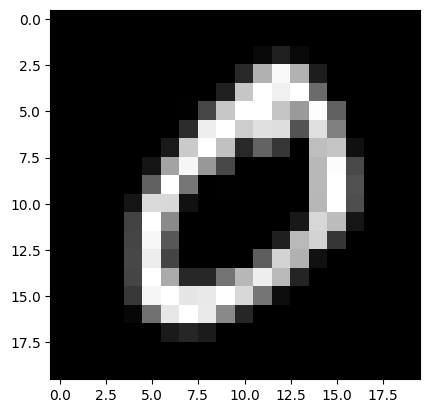

In [8]:
#Dividimos la imagen en 50x100 imagenes de 20x20
height, width = imagen.shape
print("Height:", height)
print("Width:", width)

divisions = [np.hsplit(i,100) for i in np.vsplit(imagen, 50)]
plt.imshow(divisions[0][0], cmap='gray')

In [13]:
#Separamos las imagenes en train y test

divisions = np.array(divisions)

train_images = divisions[:,:50].reshape(-1,400).astype(np.float32) 

test_images = divisions[:,50:].reshape(-1,400).astype(np.float32)

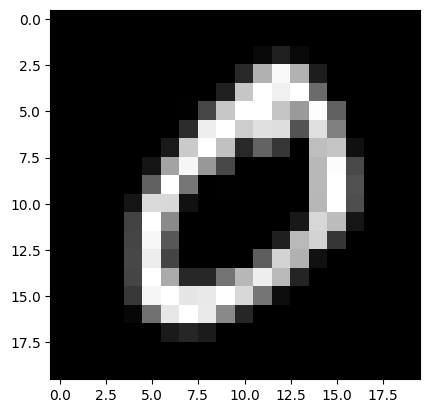

In [12]:
plt.imshow(train_images[0].reshape(20,20), cmap='gray')

In [23]:
# Creamos los labels para las imagenes de train y test
k = np.arange(10)
train_labels = np.repeat(k,250).reshape(-1,1)
test_labels = np.repeat(k,250).reshape(-1,1)

In [24]:
train_labels

array([[0],
       [0],
       [0],
       ...,
       [9],
       [9],
       [9]], shape=(2500, 1))

Usaremos el modelo KNN de cv2 pero podriamos usar el de sklearn

In [25]:
knn = cv2.ml.KNearest_create()

knn.train(train_images,
          cv2.ml.ROW_SAMPLE,
          train_labels)

True

In [26]:
ret, output ,neighbours, distance = knn.findNearest(test_images, k = 3) 

In [28]:
output == test_labels

array([[ True],
       [ True],
       [ True],
       ...,
       [ True],
       [ True],
       [ True]], shape=(2500, 1))

In [32]:
#Vemos cuales estan bien
correct = np.count_nonzero(output == test_labels)
accuracy = correct * 100.0 / output.size

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 91.64%


In [36]:
#Ahora usando sklearn
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)

model.fit(train_images, train_labels.ravel())

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [43]:
from sklearn.metrics import accuracy_score

test_predictions = model.predict(test_images)

accuracy = accuracy_score(test_labels.ravel(), test_predictions)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 91.64%


Mismo resultado pero esta mas optimizado el de cv2 para imagenes